In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from setuptools.command.rotate import rotate
from zarr.core.strings import cast_array

from src.maps import plot_grid, coordinates_conversion_equirectancular_m180

mpl.style.use('default')

import astropy.units as u

from astropy.coordinates import SkyCoord

from config.settings import CATALOG_DIR

In [2]:
catalog = pd.read_csv(f"{CATALOG_DIR}/catalog_description.csv")
catalog["ICRS"] = SkyCoord(ra=catalog["RA"], dec=catalog["Dec"], unit='deg', frame='icrs')
catalog["Gal"] = [catalog["ICRS"][i].galactic for i in catalog.index]
delta = 1e-5 * u.deg
ra_1 = [catalog["ICRS"][i].ra + delta for i in catalog.index]
ICRS_delta = SkyCoord(ra=ra_1, dec=catalog["Dec"], unit='deg', frame='icrs')
Gal_delta = ICRS_delta.galactic
catalog["angle"] = [catalog["Gal"][i].position_angle(Gal_delta[i]).to(u.deg) for i in catalog.index]
catalog

,Name,RA,Dec,Scale,Type,ICRS,Gal,angle
0,B2224+65,22h24m,65.00,1,S,"<SkyCoord (ICRS): (ra, dec) in deg\n (336.,...","<SkyCoord (Galactic): (l, b) in deg\n (108....",122d29m51.0632176s
1,G0.13-0.11,0h13m,-0.11,1,C,"<SkyCoord (ICRS): (ra, dec) in deg\n (3.25,...","<SkyCoord (Galactic): (l, b) in deg\n (102....",108d06m32.72559608s
2,J1101-6101,11h01m,-61.01,1,S,"<SkyCoord (ICRS): (ra, dec) in deg\n (165.2...","<SkyCoord (Galactic): (l, b) in deg\n (289....",65d38m13.39679677s
3,J1509-5850,15h09m,-58.50,1,S,"<SkyCoord (ICRS): (ra, dec) in deg\n (227.2...","<SkyCoord (Galactic): (l, b) in deg\n (320....",120d10m43.38846538s
4,J1740+1000,17h40m,10.00,1,C,"<SkyCoord (ICRS): (ra, dec) in deg\n (265.,...","<SkyCoord (Galactic): (l, b) in deg\n (33.9...",154d37m53.88711948s
5,J1957+5033,19h57m,50.33,1,C,"<SkyCoord (ICRS): (ra, dec) in deg\n (299.2...","<SkyCoord (Galactic): (l, b) in deg\n (84.3...",150d25m57.375039s
6,J2030+4415,20h30m,44.15,1,S,"<SkyCoord (ICRS): (ra, dec) in deg\n (307.5...","<SkyCoord (Galactic): (l, b) in deg\n (82.1...",144d05m51.15905626s
7,J2055+2539,20h55m,25.39,1,S,"<SkyCoord (ICRS): (ra, dec) in deg\n (313.7...","<SkyCoord (Galactic): (l, b) in deg\n (70.3...",141d29m02.38047245s


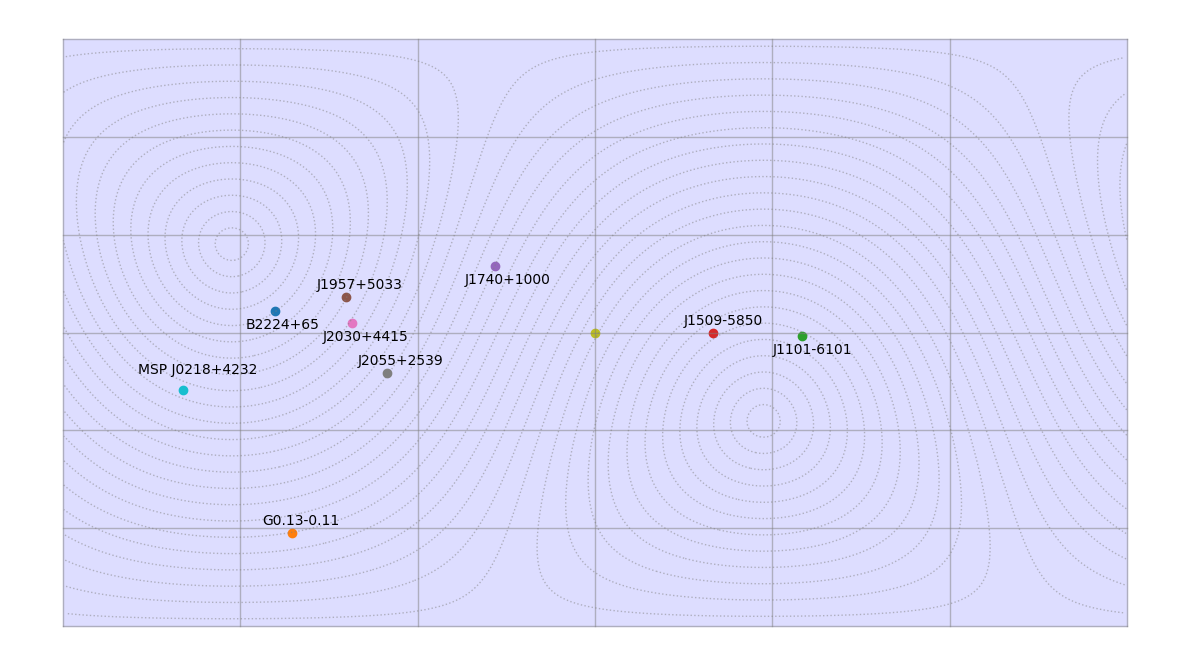

In [12]:
plt.figure(figsize=(12, 6.75))
plt.axis('off')
cc = coordinates_conversion_equirectancular_m180

plot_grid(coordinates_conversion=cc, lambda_brd=[-180, 180])

for i in catalog.index:
    l_i, b_i = catalog["Gal"][i].l.deg, catalog["Gal"][i].b.deg
    x_i, y_i = cc(l_i, b_i)
    plt.scatter(x_i, y_i)
    plt.text(x_i-10, y_i+(-1)**(i-1) * 4 - 1.5, f"{catalog['Name'][i]}")

dec_line = np.linspace(0, 360, 1000) * u.deg
for dec in range(-90, 90, 5):
    dec_line_1 = SkyCoord(ra=dec_line, dec=dec * u.deg, frame='icrs').galactic
    x, y = cc(dec_line_1.l.deg, dec_line_1.b.deg)
    cnt = [0]
    for i1 in range(1, len(x)):
        if abs(x[i1] - x[i1-1]) > 180:
            cnt.append(i1)
    for i in range(1, len(cnt)):
        plt.plot(x[cnt[i-1]:cnt[i]], y[cnt[i-1]:cnt[i]], color="gray", alpha=0.5, linestyle=":", linewidth=1)
    plt.plot(x[cnt[-1]:], y[cnt[-1]:], color="gray", alpha=0.5, linestyle=":", linewidth=1)

pts_GC = SkyCoord(l=0, b=0, frame='galactic', unit='deg')
plt.scatter(*cc(pts_GC.l.deg, pts_GC.b.deg))

pts_peanut = SkyCoord(ra="02h18m", dec=42.32, unit='deg', frame='icrs').galactic
x_peanut, y_peanut = cc(pts_peanut.l.deg, pts_peanut.b.deg)
plt.scatter(x_peanut, y_peanut)
plt.text(x_peanut-15, y_peanut+5, "MSP J0218+4232")

plt.tight_layout()
plt.savefig("catalog_map.png", dpi=300)